# IS 4487 Lab 7: Data Transformation

### Outline
- Load and preview the cleaned Megatelco dataset
- Engineer new columns from existing data
- Simplify or group variable values
- Use `.map()`, `.apply()`, and `pd.cut()` for transformations
- Try your own transformation logic

This lab continues from Lab 6, where we cleaned the Megatelco dataset.
Now, we will create new, more useful features for modeling and exploration.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Labs/lab_07_data_transformation.ipynb)

## 1. Data Cleaning steps from Lab 6

In this part of the lab, we will load the cleaning steps previously done in lab 6

- Load the Megatelco dataset
- Clean column names
- Fix data types
- Handle missing values
- Remove duplicate records
- Review for outliers

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/Stan-Pugsley/is_4487_base/refs/heads/main/DataSets/megatelco_leave_survey_data_cleaning_v2.csv"
df = pd.read_csv(url)

df.head()

,college,income,data_overage_mb,data_leftover_mb,data_mb_used,text_message_count,house,handset_price,over_15mins_calls_per_month,average_call_duration,reported_satisfaction,reported_usage_level,considering_change_of_plan,leave,id,operating_system
0,one,403137.0,70,0.0,6605.0,199,841317,653.0,5.0,8.0,low,low,yes,LEAVE,8183,Android
1,zero,129700.0,67,16.0,6028.0,134,476664,1193.0,5.0,5.0,low,low,yes,LEAVE,12501,IOS
2,zero,69741.0,60,0.0,1482.0,176,810225,1037.0,3.0,8.0,low,low,yes,STAY,7425,IOS
3,one,377572.0,0,22.0,3005.0,184,826967,1161.0,0.0,5.0,low,low,no,LEAVE,13488,IOS
4,zero,382080.0,0,0.0,1794.0,74,951896,1023.0,0.0,14.0,low,low,yes,STAY,11389,IOS


In [2]:
#check datatypes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15016 entries, 0 to 15015
Data columns (total 16 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   college                      15016 non-null  object 
 1   income                       15006 non-null  float64
 2   data_overage_mb              15016 non-null  int64  
 3   data_leftover_mb             14916 non-null  float64
 4   data_mb_used                 14916 non-null  float64
 5   text_message_count           15016 non-null  int64  
 6   house                        15016 non-null  int64  
 7   handset_price                14916 non-null  float64
 8   over_15mins_calls_per_month  15013 non-null  float64
 9   average_call_duration        14916 non-null  float64
 10  reported_satisfaction        15016 non-null  object 
 11  reported_usage_level         15016 non-null  object 
 12  considering_change_of_plan   14201 non-null  object 
 13  leave           

#### Standardize column names
- Remove leading/trailing whitespace
- Convert to lowercase
- Replace spaces with underscores

In [3]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

# Show info about data types and non-null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15016 entries, 0 to 15015
Data columns (total 16 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   college                      15016 non-null  object 
 1   income                       15006 non-null  float64
 2   data_overage_mb              15016 non-null  int64  
 3   data_leftover_mb             14916 non-null  float64
 4   data_mb_used                 14916 non-null  float64
 5   text_message_count           15016 non-null  int64  
 6   house                        15016 non-null  int64  
 7   handset_price                14916 non-null  float64
 8   over_15mins_calls_per_month  15013 non-null  float64
 9   average_call_duration        14916 non-null  float64
 10  reported_satisfaction        15016 non-null  object 
 11  reported_usage_level         15016 non-null  object 
 12  considering_change_of_plan   14201 non-null  object 
 13  leave           

#### Convert Datatypes
These steps were used in Lab 6. We will use them again to get a usable dataframe.

In [4]:
# Check original data types
print("Original dtypes:\n", df.dtypes)

# Convert yes/no columns to binary categories
df['considering_change_of_plan'] = df['considering_change_of_plan'].map({'yes': 1, 'no': 0}).astype('category')
df['leave'] = df['leave'].map({'yes': 1, 'no': 0}).astype('category')  # newly added

# Convert categorical text columns to 'category' dtype
df['college'] = df['college'].astype('category')
df['reported_satisfaction'] = df['reported_satisfaction'].astype('category')
df['reported_usage_level'] = df['reported_usage_level'].astype('category')  # newly added
df['operating_system'] = df['operating_system'].astype('category')

# Convert object/text columns with limited possible values with an order to ordinal categorical columns
df['reported_satisfaction'] = pd.Categorical(df['reported_satisfaction'], categories = ['Low', 'Medium', 'High'], ordered = True)
df['reported_usage_level'] = pd.Categorical(df['reported_usage_level'], categories = ['Low', 'Medium', 'High'], ordered = True)

# Convert binary columns ('yes'/'no', 'LEAVE'/'STAY') to binary categorical
df['considering_change_of_plan'] = df['considering_change_of_plan'].astype('category')
df['leave'] = df['leave'].astype('category')

# Check updated data types
print("\nUpdated dtypes:\n", df.dtypes)

Original dtypes:
 college                         object
income                         float64
data_overage_mb                  int64
data_leftover_mb               float64
data_mb_used                   float64
text_message_count               int64
house                            int64
handset_price                  float64
over_15mins_calls_per_month    float64
average_call_duration          float64
reported_satisfaction           object
reported_usage_level            object
considering_change_of_plan      object
leave                           object
id                               int64
operating_system                object
dtype: object

Updated dtypes:
 college                        category
income                          float64
data_overage_mb                   int64
data_leftover_mb                float64
data_mb_used                    float64
text_message_count                int64
house                             int64
handset_price                   float64
over_1

### 1b. Checking the conversions before moving on

Before building anything on these columns, it's worth checking the conversions actually landed.
A `.map()` that misses returns `NaN` rather than raising, so a broken mapping stays quiet. The
dtype still says `category`, and nothing looks wrong.

In [5]:
# A mapping that doesn't match returns NaN silently, so check what survived.
for col in ['leave', 'reported_satisfaction', 'reported_usage_level', 'considering_change_of_plan']:
    print(f"{col:30s} non-null: {df[col].notna().sum():6d}    null: {df[col].isna().sum():6d}")

leave                          non-null:      0    null:  15016
reported_satisfaction          non-null:      0    null:  15016
reported_usage_level           non-null:      0    null:  15016
considering_change_of_plan     non-null:  14201    null:    815


Three columns came back **100% null**. The labels the code expects are not the labels
this CSV actually uses:

| Column | Code expects | File actually contains |
|---|---|---|
| `leave` | `'yes'` / `'no'` | `LEAVE` / `STAY` |
| `reported_satisfaction` | `Low` / `Medium` / `High` | `low` / `avg` / `high` |
| `reported_usage_level` | `Low` / `Medium` / `High` | `low` / `avg` / `high` |

That bites us later. **Part 5 asks us to one-hot encode `reported_satisfaction`**, and encoding
an all-null column just gives you dummy columns that are `False` on every row. The cell below
re-reads the source and maps the labels that are actually in it.

In [6]:
# Re-read the untouched source so we can recover the original label text.
raw = pd.read_csv(url)
raw.columns = raw.columns.str.strip().str.lower().str.replace(" ", "_")

print("Actual values in the source file:")
for col in ['leave', 'reported_satisfaction', 'reported_usage_level']:
    print(f"  {col:26s} {sorted(raw[col].dropna().unique())}")

# Map the labels that are really in the file onto the intended categories.
level_map = {'low': 'Low', 'avg': 'Medium', 'high': 'High'}

df['reported_satisfaction'] = pd.Categorical(
    raw['reported_satisfaction'].str.strip().str.lower().map(level_map),
    categories=['Low', 'Medium', 'High'], ordered=True)

df['reported_usage_level'] = pd.Categorical(
    raw['reported_usage_level'].str.strip().str.lower().map(level_map),
    categories=['Low', 'Medium', 'High'], ordered=True)

# LEAVE = churned = 1, STAY = retained = 0
df['leave'] = raw['leave'].str.strip().str.upper().map({'LEAVE': 1, 'STAY': 0}).astype('category')

print("\nAfter repair:")
for col in ['leave', 'reported_satisfaction', 'reported_usage_level']:
    print(f"\n{col}:")
    print(df[col].value_counts().to_string())

Actual values in the source file:
  leave                      ['LEAVE', 'STAY']
  reported_satisfaction      ['avg', 'high', 'low']
  reported_usage_level       ['avg', 'high', 'low']

After repair:

leave:
leave
0    7532
1    7484

reported_satisfaction:
reported_satisfaction
Low       10850
High       3415
Medium      751

reported_usage_level:
reported_usage_level
Low       12235
High       2536
Medium      245


### 1c. Finishing the Lab 6 cleaning

The section header lists *handle missing values*, *remove duplicate records* and *review for
outliers*, but the cells above only rename columns and set dtypes. Those three steps still need
to run. They matter here for one reason: **Part 4 scales `handset_price` with `MinMaxScaler`,
which is defined entirely by the column's min and max.** One bad maximum sets the scale for all
15,000 rows.

In [7]:
print("Starting shape:", df.shape)

# --- Duplicates -----------------------------------------------------------
print("Exact duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates()

# --- Outliers / impossible values ----------------------------------------
# These are data-entry errors, not real customers: negative money, a $125,000
# handset, a 5,000-minute average call.
impossible = (
    (df['income'] < 0)
    | (df['house'] < 0)
    | (df['handset_price'] < 0)
    | (df['handset_price'] > 5000)
    | (df['average_call_duration'] > 100)
    | (df['text_message_count'] > 1000)
)
print("Rows with impossible values:", int(impossible.sum()))
print(df.loc[impossible, ['income', 'house', 'handset_price',
                          'average_call_duration', 'text_message_count']].to_string())

df = df.loc[~impossible].copy()

# --- Missing values -------------------------------------------------------
numeric_cols = df.select_dtypes(include=[np.number]).columns.drop('id')
print("\nMissing values before imputing:")
print(df[numeric_cols].isna().sum()[lambda s: s > 0].to_string())

# Median, not mean: several of these columns are skewed.
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

print("\nMissing numeric values after imputing:", int(df[numeric_cols].isna().sum().sum()))
print("`considering_change_of_plan` still has",
      int(df['considering_change_of_plan'].isna().sum()),
      "missing. Survey non-response, left alone rather than invented.")
print("\nFinal shape:", df.shape)

Starting shape: (15016, 16)
Exact duplicate rows: 17
Rows with impossible values: 9
         income    house  handset_price  average_call_duration  text_message_count
19      72590.0     -463          469.0                    1.0                 106
69     -65000.0   542857          993.0                   11.0                 160
153    -32000.0  1426087          651.0                   11.0                 154
617    400819.0  1143853        20000.0                    1.0                 140
663    255920.0  1192419        75000.0                    1.0                  98
712    279209.0  1070968       125000.0                    1.0                  96
7918   138785.0  1101434         1149.0                   10.0                5000
8231   385283.0   992299         -200.0                   18.0                 134
14870  269289.0  1125604         1261.0                 5000.0                 136

Missing values before imputing:
income                          10
data_leftover_mb  

## 2. Creating New Features

A major part of data preparation is **feature engineering** — creating new columns from raw data to capture useful patterns.

In this section, we will try three common methods:
- `.map()` — useful for simplifying categories (e.g., satisfaction levels)
- `.apply()` — allows flexible custom logic (e.g., flagging high usage)
- `pd.cut()` or `pd.qcut()` — groups numeric values into bins or quantiles

These new features help models learn better and make reports easier to interpret.

**Things to think about:**
- Are any categories too specific or inconsistent?
- Can you create groups or flags to highlight important traits?
- Would a simplified version of a column help with modeling or visualization?

In [8]:
# Create a total data usage variable (used + leftover)
df['total_data_mb'] = df['data_mb_used'] + df['data_leftover_mb']

# Create a ratio of overage to used data
df['overage_ratio'] = df['data_overage_mb'] / (df['data_mb_used'] + 1)  # add 1 to avoid divide-by-zero

# Create a binary flag for high texters (over 500 texts)
df['high_texter'] = (df['text_message_count'] > 500).astype(int)

# Preview new columns
df[['total_data_mb', 'overage_ratio', 'high_texter']].head()

,total_data_mb,overage_ratio,high_texter
0,6605.0,0.010596,0
1,6044.0,0.011113,0
2,1482.0,0.040459,0
3,3027.0,0.000000,0
4,1794.0,0.000000,0


### 🔧 Do the following – Part 2
1. Create a variable called `call_volume` by multiplying `over_15mins_calls_per_month` by `average_call_duration`
2. Create a binary flag `high_data_user` for users where `data_mb_used` is above the median
3. Use `.head()` to check your new columns

In [9]:
# 1. call_volume: minutes per month spent on long calls
df['call_volume'] = df['over_15mins_calls_per_month'] * df['average_call_duration']

# 2. high_data_user: 1 if the customer uses more data than the typical customer
median_data = df['data_mb_used'].median()
df['high_data_user'] = (df['data_mb_used'] > median_data).astype(int)
print(f"Median data_mb_used: {median_data:,.0f} MB")

# 3. Check the new columns
df[['over_15mins_calls_per_month', 'average_call_duration', 'call_volume',
    'data_mb_used', 'high_data_user']].head()

Median data_mb_used: 4,220 MB


,over_15mins_calls_per_month,average_call_duration,call_volume,data_mb_used,high_data_user
0,5.0,8.0,40.0,6605.0,1
1,5.0,5.0,25.0,6028.0,1
2,3.0,8.0,24.0,1482.0,0
3,0.0,5.0,0.0,3005.0,0
4,0.0,14.0,0.0,1794.0,0


In [10]:
# Quick sanity check on the two new features
print("call_volume summary:")
print(df['call_volume'].describe().to_string())

print("\nhigh_data_user split:")
print(df['high_data_user'].value_counts().sort_index().to_string())

call_volume summary:
count    14990.000000
mean       107.204803
std        106.591109
min          0.000000
25%         19.000000
50%         75.000000
75%        168.000000
max        630.000000

high_data_user split:
high_data_user
0    7546
1    7444


## 3. Binning Continuous Variables

Binning is the process of grouping numeric variables into categories (e.g., "low", "medium", "high").

**Why We Bin:**
- Helps reduce the impact of outliers
- Allows us to use numeric values in models that prefer categories
- Simplifies interpretation and visualization

**Things to think about:**
- Would grouping values make patterns more visible?
- Do we want equal-sized groups or logical cutoffs?
- Is the variable skewed?

**Tools:**
- `pd.qcut()` for quantile-based bins (equal frequency)
- `pd.cut()` for equal-width or custom bins

In [11]:
# Bin income into 3 groups (quantiles): Low, Medium, High
df['income_group'] = pd.qcut(df['income'], q=3, labels=['Low', 'Medium', 'High'])

# Bin average call duration into quartiles (labels as integers)
df['call_duration_group'] = pd.qcut(df['average_call_duration'], q=4, labels=False)

# Preview new groupings
df[['income', 'income_group', 'average_call_duration', 'call_duration_group']].head()

,income,income_group,average_call_duration,call_duration_group
0,403137.0,High,8.0,1
1,129700.0,Low,5.0,0
2,69741.0,Low,8.0,1
3,377572.0,High,5.0,0
4,382080.0,High,14.0,2


### 🔧 Do the following – Part 3
1. Use `pd.cut()` to group `data_mb_used` into 3 labeled bins: "Light", "Moderate", "Heavy"
2. Use `pd.qcut()` on `text_message_count` to split into 4 equal-sized groups
3. Print `.value_counts()` on each new column to see how values are distributed

In [12]:
# 1. pd.cut(): 3 EQUAL-WIDTH bins. cut splits the range, not the customers.
df['data_usage_group'] = pd.cut(df['data_mb_used'], bins=3,
                                labels=['Light', 'Moderate', 'Heavy'])

# 2. pd.qcut(): 4 EQUAL-FREQUENCY groups, same number of customers in each
df['text_message_group'] = pd.qcut(df['text_message_count'], q=4,
                                   labels=['Q1', 'Q2', 'Q3', 'Q4'])

# 3. Distribution of each new column
print("data_usage_group (pd.cut, equal width):")
print(df['data_usage_group'].value_counts().sort_index().to_string())

print("\ntext_message_group (pd.qcut, equal frequency):")
print(df['text_message_group'].value_counts().sort_index().to_string())

data_usage_group (pd.cut, equal width):
data_usage_group
Light       4985
Moderate    4983
Heavy       5022

text_message_group (pd.qcut, equal frequency):
text_message_group
Q1    3784
Q2    3729
Q3    3774
Q4    3703


In [13]:
# The bin edges show what each method actually did
print("cut  edges (equal width) :", pd.cut(df['data_mb_used'], bins=3).cat.categories.tolist())
print("qcut edges (equal count) :", pd.qcut(df['text_message_count'], q=4).cat.categories.tolist())

cut  edges (equal width) : [Interval(392.4, 2933.333, closed='right'), Interval(2933.333, 5466.667, closed='right'), Interval(5466.667, 8000.0, closed='right')]
qcut edges (equal count) : [Interval(51.999, 93.0, closed='right'), Interval(93.0, 135.0, closed='right'), Interval(135.0, 178.0, closed='right'), Interval(178.0, 220.0, closed='right')]


## 4. Scaling Numeric Variables

Scaling transforms values to a common range (often 0–1), which helps many machine learning models perform better.

**When to Scale:**
- When features have very different ranges (e.g., income vs. call duration)
- When using distance-based models (e.g., KNN, SVM)
- When comparing magnitudes across features

**Common Methods:**
- `MinMaxScaler`: scales to 0–1 range
- `StandardScaler`: centers data around 0 with unit variance

**Things to think about:**
- Are features on different scales?
- Does my algorithm care about magnitude?

In [14]:
from sklearn.preprocessing import MinMaxScaler

# Choose columns to scale
cols_to_scale = ['income', 'data_mb_used', 'average_call_duration']

# Initialize and apply scaler
scaler = MinMaxScaler()
df_scaled = scaler.fit_transform(df[cols_to_scale])

# Add scaled columns back to df
df['income_scaled'] = df_scaled[:, 0]
df['data_mb_used_scaled'] = df_scaled[:, 1]
df['avg_call_dur_scaled'] = df_scaled[:, 2]

# Preview
df[['income_scaled', 'data_mb_used_scaled', 'avg_call_dur_scaled']].head()

,income_scaled,data_mb_used_scaled,avg_call_dur_scaled
0,0.923946,0.816447,0.388889
1,0.203444,0.740526,0.222222
2,0.045453,0.142368,0.388889
3,0.856583,0.342763,0.222222
4,0.868462,0.183421,0.722222


### 🔧 Do the following – Part 4
1. Scale the `handset_price` and `over_15mins_calls_per_month` columns using `MinMaxScaler`
2. Add the scaled values back to the dataframe using 2 new columns with suffix `_scaled`
3. Use `.describe()` to compare original vs. scaled versions

In [15]:
# 1. Scale the two requested columns
cols_to_scale_2 = ['handset_price', 'over_15mins_calls_per_month']

scaler2 = MinMaxScaler()
scaled_2 = scaler2.fit_transform(df[cols_to_scale_2])

# 2. Add them back with the _scaled suffix
df['handset_price_scaled'] = scaled_2[:, 0]
df['over_15mins_calls_per_month_scaled'] = scaled_2[:, 1]

# 3. Compare original vs scaled
comparison = df[['handset_price', 'handset_price_scaled',
                 'over_15mins_calls_per_month', 'over_15mins_calls_per_month_scaled']].describe().T
print(comparison.to_string())

print("\nMin and max the scaler learned from each column:")
for col, lo, hi in zip(cols_to_scale_2, scaler2.data_min_, scaler2.data_max_):
    print(f"  {col:30s} min={lo:>8,.1f}   max={hi:>8,.1f}")

                                      count        mean         std    min         25%         50%          75%     max
handset_price                       14990.0  780.429153  325.474233  215.0  499.000000  777.000000  1062.000000  1350.0
handset_price_scaled                14990.0    0.498175    0.286761    0.0    0.250220    0.495154     0.746256     1.0
over_15mins_calls_per_month         14990.0   10.570247    8.400769    0.0    3.000000    9.000000    17.000000    35.0
over_15mins_calls_per_month_scaled  14990.0    0.302007    0.240022    0.0    0.085714    0.257143     0.485714     1.0

Min and max the scaler learned from each column:
  handset_price                  min=   215.0   max= 1,350.0
  over_15mins_calls_per_month    min=     0.0   max=    35.0


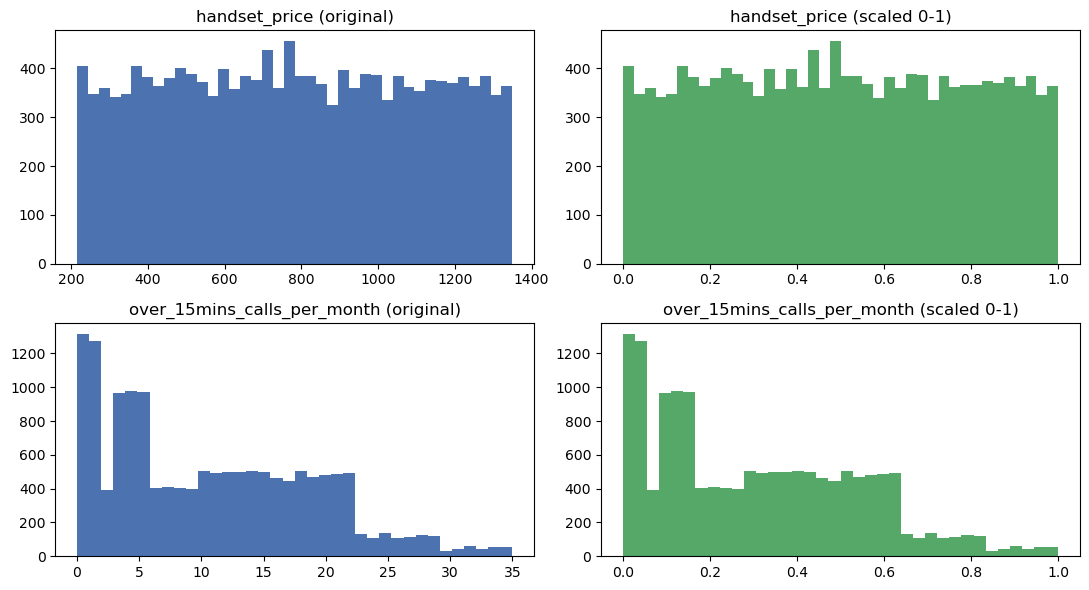

In [16]:
# Visual check: the shape of each distribution is unchanged, only the x-axis moves.
fig, axes = plt.subplots(2, 2, figsize=(11, 6))

axes[0, 0].hist(df['handset_price'], bins=40, color='#4C72B0')
axes[0, 0].set_title('handset_price (original)')
axes[0, 1].hist(df['handset_price_scaled'], bins=40, color='#55A868')
axes[0, 1].set_title('handset_price (scaled 0-1)')

axes[1, 0].hist(df['over_15mins_calls_per_month'], bins=36, color='#4C72B0')
axes[1, 0].set_title('over_15mins_calls_per_month (original)')
axes[1, 1].hist(df['over_15mins_calls_per_month_scaled'], bins=36, color='#55A868')
axes[1, 1].set_title('over_15mins_calls_per_month (scaled 0-1)')

plt.tight_layout()
plt.show()

In [17]:
# Why the outlier removal in section 1c mattered, in one number.
# Re-scale handset_price with the original uncleaned values for comparison.
dirty_price = pd.read_csv(url)
dirty_price.columns = dirty_price.columns.str.strip().str.lower().str.replace(" ", "_")
dirty_price = dirty_price[['handset_price']].fillna(dirty_price['handset_price'].median())

dirty_scaled = MinMaxScaler().fit_transform(dirty_price)

print("handset_price scaled WITH the $125,000 outlier still in:")
print(pd.Series(dirty_scaled[:, 0]).describe().to_string())
print("\nhandset_price scaled AFTER cleaning:")
print(df['handset_price_scaled'].describe().to_string())

handset_price scaled WITH the $125,000 outlier still in:
count    15016.000000
mean         0.007946
std          0.009863
min          0.000000
25%          0.005583
50%          0.007804
75%          0.010080
max          1.000000

handset_price scaled AFTER cleaning:
count    14990.000000
mean         0.498175
std          0.286761
min          0.000000
25%          0.250220
50%          0.495154
75%          0.746256
max          1.000000


#### Reflection:
4.1 Make a comment on what you observe in your comparison

✍️ **Your Response:** 🔧

**4.1** Same shape, just a new range. `handset_price` used to run \$215 to \$1,350 and now it sits
between 0 and 1, averaging about 0.50. `over_15mins_calls_per_month` went from 0 to 35 calls to
a 0.30 average, still under the middle, because scaling only squeezes the axis. It doesn't touch
the skew. What got me was the second comparison. Leave that \$125,000 handset in and the same
scaler drops the average to 0.008, with three quarters of customers crammed under 0.010. So:
clean it, then scale it.

## 5. Encoding Categorical Variables

Most machine learning models can't handle string categories directly—so we convert them into numbers using **encoding**.

**Types of Encoding:**
- **One-hot encoding**: creates a binary column for each unique value in the original categorical column (**used for nominal variables**)
  - an example: We have a column called Colors with 3 values: red, blue, green - that we want to treat as nominal. OHE will create 3 new columns corresponidng to each color, and place a 1 in the new column, wherever the value in original column matches the color in its colname.
  - The original column is dropped by default, so it adds n new colums where n = number of unique values

| Color | red | blue | green |
|---|---|---|---|
| red | 1 | 0 | 0 |
| blue | 0 | 1 | 0 |
| green | 0 | 0 | 1 |
| red | 1 | 0 | 0 |

- **Ordinal encoding**: assigns integers (use only for ordered categories)
  - An example: if we have a column called Education, we may want to set their values as 1,2,3,.....
  - adds only one new column, original column remains.

| Education | educ_int |
|---|---|
| some high school | 1 |
| high school grad | 2 |
| some college | 3 |
| college grad | 4 |

**Things to consider:**
- Is the variable nominal (e.g., OS type) or ordinal (e.g., satisfaction)?
- How many unique categories are there?
- Will one-hot encoding make the dataset too wide?

**Tool:** `pd.get_dummies()`

In [18]:
# One-hot encode 'reported_usage_level'
df_encoded = pd.get_dummies(df, columns=['reported_usage_level'], prefix='usage')

# One-hot encode 'income_group'
df_encoded = pd.get_dummies(df_encoded, columns=['income_group'], prefix='income')

# Preview new columns
df_encoded.filter(like='usage_').head()

,data_usage_group,usage_Low,usage_Medium,usage_High
0,Heavy,True,False,False
1,Heavy,True,False,False
2,Light,True,False,False
3,Moderate,True,False,False
4,Light,True,False,False


### 🔧 Do the following – Part 5
1. One-hot encode `reported_satisfaction` and `operating_system`
2. Print `.shape` of your dataframe before and after to observe any big changes

In [19]:
# 2. Shape before
print("Shape BEFORE encoding:", df_encoded.shape)

# 1. One-hot encode the two columns
df_encoded = pd.get_dummies(df_encoded,
                            columns=['reported_satisfaction', 'operating_system'],
                            prefix=['satisfaction', 'os'])

# 2. Shape after
print("Shape AFTER encoding :", df_encoded.shape)

new_cols = [c for c in df_encoded.columns if c.startswith(('satisfaction_', 'os_'))]
print(f"\nColumns added ({len(new_cols)}): {new_cols}")
print("Net change: 2 original columns dropped, "
      f"{len(new_cols)} dummy columns added.")

Shape BEFORE encoding: (14990, 34)
Shape AFTER encoding : (14990, 37)

Columns added (5): ['satisfaction_Low', 'satisfaction_Medium', 'satisfaction_High', 'os_Android', 'os_IOS']
Net change: 2 original columns dropped, 5 dummy columns added.


In [20]:
# Confirm the encoding is real and not all-False (the problem caught in section 1b)
print(df_encoded[new_cols].head().to_string())

print("\nRows flagged in each new column:")
print(df_encoded[new_cols].sum().to_string())

   satisfaction_Low  satisfaction_Medium  satisfaction_High  os_Android  os_IOS
0              True                False              False        True   False
1              True                False              False       False    True
2              True                False              False       False    True
3              True                False              False       False    True
4              True                False              False       False    True

Rows flagged in each new column:
satisfaction_Low       10835
satisfaction_Medium      750
satisfaction_High       3405
os_Android              7797
os_IOS                  7193


#### Reflection:
5.1 How many new columns were added? Are they useful for your objective?

✍️ **Your Response:** 🔧

**5.1** Five of them: `satisfaction_Low`, `satisfaction_Medium`, `satisfaction_High`,
`os_Android`, `os_IOS`. The two originals drop out, so I really only gain three. They're worth
having, since no model is going to read the word `Android` on its own, and both feel like real
churn signals. Two things nag at me though. `reported_satisfaction` has an order to it, and
one-hot flattens that out, so nothing tells the model High beats Low. And `operating_system` is
binary, so `os_Android` and `os_IOS` are just mirrors. One of them is doing nothing.

## 🔧 6. Reflection (100 words or less per question)

- 6.1 Which transformation do you think had the biggest impact on preparing your data for modeling?
- 6.2 Are there any features you created that you think will be especially useful for predicting churn?

In [21]:
# Evidence for 6.2: do the engineered features actually separate churners?
df['churn'] = df['leave'].astype(float)
print("Baseline churn rate:", round(df['churn'].mean(), 3))
print()

for col in ['high_data_user', 'data_usage_group', 'text_message_group']:
    r = df.groupby(col, observed=True)['churn'].agg(['mean', 'size'])
    r.columns = ['churn_rate', 'customers']
    print(f"--- churn rate by {col} ---")
    print(r.round(3).to_string())
    print()

# high_texter was built before the cleaning step - check that it still varies
print("high_texter unique values:", df['high_texter'].unique(),
      "| max text_message_count:", df['text_message_count'].max())

Baseline churn rate: 0.498

--- churn rate by high_data_user ---
                churn_rate  customers
high_data_user                       
0                    0.497       7546
1                    0.500       7444

--- churn rate by data_usage_group ---
                  churn_rate  customers
data_usage_group                       
Light                  0.501       4985
Moderate               0.500       4983
Heavy                  0.495       5022

--- churn rate by text_message_group ---
                    churn_rate  customers
text_message_group                       
Q1                       0.498       3784
Q2                       0.495       3729
Q3                       0.497       3774
Q4                       0.504       3703

high_texter unique values: [0] | max text_message_count: 220


In [22]:
# Rank features by how far apart their quartile churn rates are.
# A flat row (all four near 0.50) means the feature carries no signal.
rows = []
for col in ['overage_ratio', 'call_volume', 'data_overage_mb', 'over_15mins_calls_per_month',
            'total_data_mb', 'data_mb_used', 'text_message_count', 'income',
            'handset_price', 'house']:
    q = pd.qcut(df[col], 4, labels=['Q1', 'Q2', 'Q3', 'Q4'], duplicates='drop')
    r = df.groupby(q, observed=True)['churn'].mean()
    rows.append([col] + [round(v, 3) for v in r.values] + [round(r.max() - r.min(), 3)])

ranking = (pd.DataFrame(rows, columns=['feature', 'Q1', 'Q2', 'Q3', 'Q4', 'spread'])
             .sort_values('spread', ascending=False))
print("Churn rate by quartile, ranked by spread:")
print(ranking.to_string(index=False))

Churn rate by quartile, ranked by spread:
                    feature    Q1    Q2    Q3    Q4  spread
                      house 0.752 0.507 0.516 0.220   0.532
            data_overage_mb 0.440 0.497 0.555 0.501   0.115
over_15mins_calls_per_month 0.441 0.504 0.521 0.532   0.091
              overage_ratio 0.439 0.519 0.519 0.517   0.080
                call_volume 0.446 0.523 0.511 0.515   0.078
                     income 0.507 0.500 0.503 0.483   0.023
               data_mb_used 0.498 0.496 0.509 0.491   0.018
              total_data_mb 0.499 0.496 0.508 0.491   0.017
         text_message_count 0.498 0.495 0.497 0.504   0.009
              handset_price 0.500 0.497 0.497 0.499   0.004


✍️ **Your Response:** 🔧

**6.1** Honestly, fixing those category conversions back in 1b. It's not exciting next to
scaling or binning, but three columns had gone completely null without saying a word, and one of
them was `leave`, the thing we're trying to predict. The code looks for `'yes'` and `'no'` in a
file that says `LEAVE` and `STAY`, and `.map()` just shrugs when it misses. Everything after it
inherits the problem. Part 5 would have handed me dummy columns that were False on every single
row. Dropping the junk rows is a close second, for the same reason.

**6.2** Not the ones I thought. `high_data_user` and `data_usage_group` both sit around 50% churn
in every bucket, which is just the baseline, so they tell me nothing.
`high_texter` is even worse. Once that outlier row went, nothing goes above 220 texts, so the
column is all zeros and there's nothing to learn from it. I'd keep `overage_ratio` and
`call_volume`; each pulls its bottom quarter to roughly 44% against 52% elsewhere. And the best
signal in the file wasn't built by me at all. `house` goes from 100% churn at the bottom to 0%
at the top.

## Export Your Notebook to Submit in Canvas
- Use the instructions from Lab 1

In [23]:
!jupyter nbconvert --to html "lab_07_data_transformation.ipynb"

[NbConvertApp] Converting notebook lab_07_data_transformation.ipynb to html


[NbConvertApp] Writing 365623 bytes to lab_07_data_transformation.html
